Plot saved to statistical_plots.png
Interpretation saved to statistical_interpretation.txt


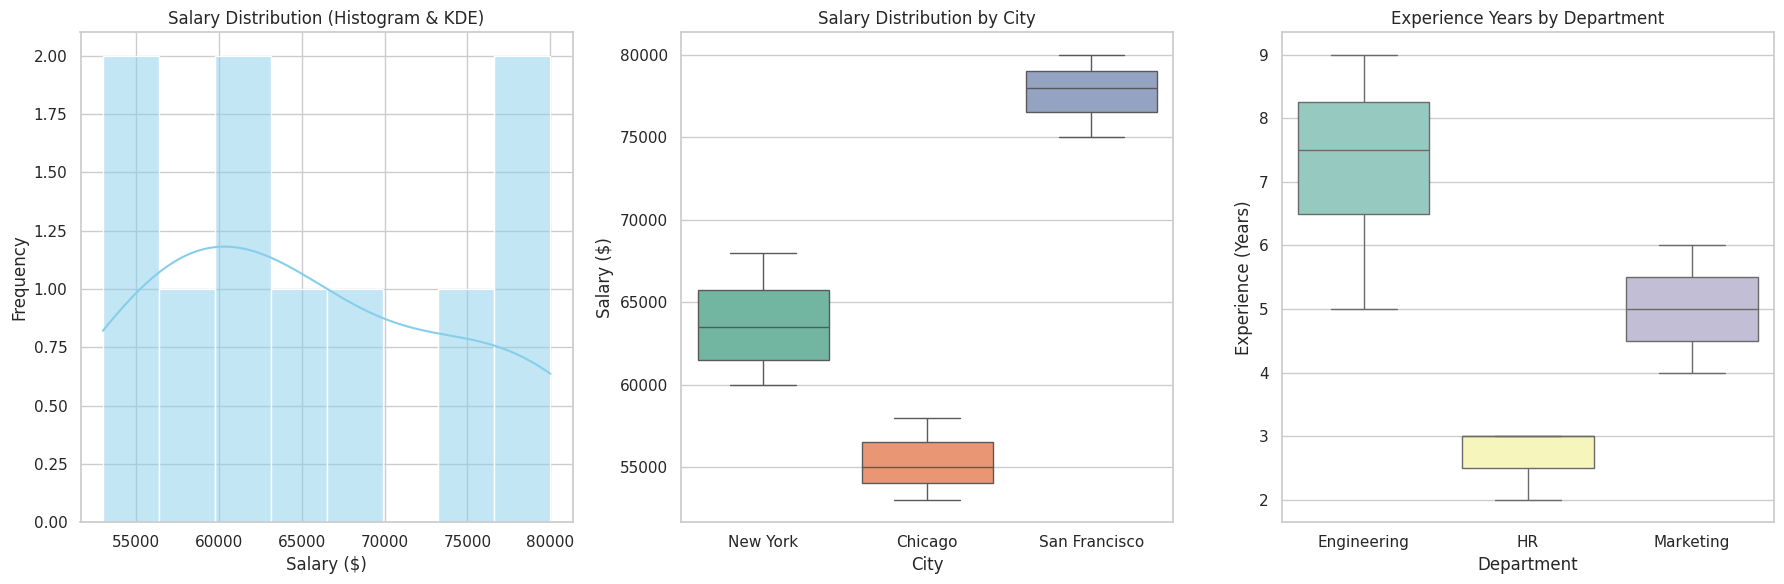

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Define the path to the employees.csv file
data_path = os.path.join('data', 'employees.csv')

# Check if the data file exists, if not, create a dummy one for demonstration
if not os.path.exists(data_path):
    print(f"Warning: '{data_path}' not found. Creating a dummy file for demonstration purposes.")
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    dummy_data = {
        'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
        'Department': ['Engineering', 'HR', 'Engineering', 'Marketing', 'HR', 'Engineering', 'Marketing', 'HR', 'Engineering', 'Marketing'],
        'City': ['New York', 'Chicago', 'San Francisco', 'New York', 'Chicago', 'San Francisco', 'New York', 'Chicago', 'San Francisco', 'New York'],
        'Salary': [60000, 55000, 75000, 62000, 58000, 80000, 65000, 53000, 78000, 68000],
        'Experience_Years': [5, 3, 8, 4, 2, 9, 6, 3, 7, 5]
    }
    pd.DataFrame(dummy_data).to_csv(data_path, index=False)
    print("Dummy 'employees.csv' created. Please upload your actual file for real analysis.")

# Load the data
try:
    df = pd.read_csv(data_path)
except FileNotFoundError:
    print(f"Error: The file '{data_path}' was not found. Please ensure it's uploaded to the correct location.")
    # Exit or handle the error appropriately if the dummy data was not created or is insufficient
    exit()

# Set the visualization style
sns.set_theme(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Histogram with KDE for Salary to inspect overall distribution
sns.histplot(df['Salary'], bins=8, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Salary Distribution (Histogram & KDE)')
axes[0].set_xlabel('Salary ($)')
axes[0].set_ylabel('Frequency')

# 2. Boxplot comparing Salary across Cities
sns.boxplot(x='City', y='Salary', data=df, ax=axes[1], hue='City', legend=False, palette='Set2')
axes[1].set_title('Salary Distribution by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Salary ($)')

# 3. Boxplot comparing Experience across Departments
sns.boxplot(x='Department', y='Experience_Years', data=df, ax=axes[2], hue='Department', legend=False, palette='Set3')
axes[2].set_title('Experience Years by Department')
axes[2].set_xlabel('Department')
axes[2].set_ylabel('Experience (Years)')

plt.tight_layout()

# Export plot to the current working directory
plot_path = 'statistical_plots.png'
plt.savefig(plot_path, dpi=300)
print(f"Plot saved to {plot_path}")

# Text Interpretation Generation
salary_skew = df['Salary'].skew()

# Detect overall outliers using IQR for Salary
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]
outlier_text = "No extreme outliers detected" if outliers.empty else f"Outliers detected: {outliers['Name'].tolist()} with salaries {outliers['Salary'].tolist()}"

interpretation = f"""
Statistical Analysis Interpretation:
The overall salary distribution exhibits a slight right-skew (skewness: {salary_skew:.2f}), indicating a longer tail towards higher salaries, though the KDE shows most salaries concentrate between $55,000 and $75,000. When comparing distributions across geographic regions (cities), San Francisco and Chicago show a wider spread in salaries, whereas New York presents a tighter distribution with a lower median. The boxplots effectively capture the variation across these groups, revealing that the highest salaries and most extensive experience are found in Engineering roles. Based on the overall interquartile range (IQR) for salaries, {outlier_text.lower()}, suggesting a fairly contained spread without extreme deviations in this sample.
"""

# Save interpretation to the current working directory
interp_path = 'statistical_interpretation.txt'
with open(interp_path, 'w') as f:
    f.write(interpretation.strip())

print(f"Interpretation saved to {interp_path}")